# Population-Specific Effects of Pathogenic UTR Variants

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.utils as utils
import src.clinvar as cv

 ## 1. Load Data

In [2]:
variant_set="clinvar_utr_snv"
vep_df = vp.load_vep_results_mfdataset(xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
), 
    dropna_subset=["flashzoi"]
    )
vep_df.head()

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs

,site,sample,ploid,slot,evo2_40b_base,evo2_7b,flashzoi,spliceai,dnabert2,spliceai_mm,evo2_40b,evo2_7b_base
356860,chr21:25714732-25714733_T_C,REF,0,COVR,NaN,NaN,3.582652,NaN,NaN,NaN,NaN,NaN
356864,chr21:25714732-25714733_T_C,REF,0,delta_abs_mean,NaN,NaN,0.000995,NaN,NaN,NaN,NaN,NaN
356865,chr21:25714732-25714733_T_C,REF,0,delta_max_max,NaN,NaN,2.838457,NaN,NaN,NaN,NaN,NaN
356866,chr21:25714732-25714733_T_C,REF,0,delta_mean,NaN,NaN,0.000149,NaN,NaN,NaN,NaN,NaN
356867,chr21:25714732-25714733_T_C,REF,0,delta_pow2_mean,NaN,NaN,0.000056,NaN,NaN,NaN,NaN,NaN


In [3]:
vep_df = vep_df.loc[vep_df["slot"]=="COVR"]
vep_df = va.add_onekg_metadata(vep_df)

In [5]:
bed_utr = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz", 
                      extract_ids=True,
                      simplify=True) 

Extracting ID columns.
Adding ID counts.
Using default maps.
Simplifying annotations.


In [8]:

bed_utr = bed_utr.to_pandas()
if 'name' in bed_utr.columns:
    annotation_df = bed_utr.rename(columns={'name': 'site'})
annotation_cols = [
    'site', 'CLNSIG', 'CLNSIG_simple', 'CLNSIG_super_simple',
    'CLNSIGCONF', 'CLNREVSTAT', 'CLNREVSTAT_score'
]
if 'GENE' in annotation_df.columns:
    annotation_cols.insert(1, 'GENE')
annotation_df = annotation_df[[col for col in annotation_cols if col in annotation_df.columns]]
vep_df = vep_df.merge(annotation_df, on='site', how='left')


In [9]:

# Filter for the slot you want (e.g., "COVR")
vep_df_covr = vep_df[vep_df['slot'] == 'COVR'].copy()

# Variance of flashzoi for each SNP (site)
snp_var = vep_df_covr.groupby('site')['flashzoi'].var().rename('flashzoi_var')

# Variance of mean population flashzoi for each SNP
pop_means = vep_df_covr.groupby(['site', 'Population'])['flashzoi'].mean().reset_index()
pop_var_of_means = pop_means.groupby('site')['flashzoi'].var().rename('flashzoi_popmean_var')

# Variance within each population for each SNP
pop_within_var = vep_df_covr.groupby(['site', 'Population'])['flashzoi'].var().rename('flashzoi_withinpop_var')

# Merge these as columns
vep_df_covr = vep_df_covr.merge(snp_var, on='site', how='left')
vep_df_covr = vep_df_covr.merge(pop_within_var, on=['site', 'Population'], how='left')
vep_df_covr = vep_df_covr.merge(pop_var_of_means, on='site', how='left')

In [10]:

# Columns to keep in the output
extra_cols = [
    'CLNSIG', 'CLNSIG_simple', 'CLNSIG_super_simple',
    'CLNSIGCONF', 'CLNREVSTAT', 'CLNREVSTAT_score'
]

# For each extra column, if missing or all NaN, merge it back in from the original vep_df
for col in extra_cols:
    if col not in vep_df_covr.columns or vep_df_covr[col].isnull().all():
        vep_df_covr = vep_df_covr.drop(columns=[col], errors='ignore')
        # Only merge if the column exists in the original DataFrame
        if col in vep_df.columns:
            vep_df_covr = vep_df_covr.merge(
                vep_df[['site', col]].drop_duplicates(),
                on='site',
                how='left'
            )
        else:
            print(f"Warning: Column '{col}' not found in input data and will be left empty.")



In [1]:
# import pandas as pd

# # Load the processed results with variance and annotation columns
# df = pd.read_csv("vep_df_with_flashzoi_variances.csv")
# print(f"Loaded {len(df):,} rows.")
# df.head()

Loaded 1,942,338 rows.


,site,sample,ploid,slot,dnabert2,evo2_7b_base,spliceai_mm,evo2_40b,spliceai,evo2_40b_base,...,DNA from Blood,Offspring available from trios,Pilot Samples,Phase1 Samples,Final Phase Samples,Total,flashzoi_var,flashzoi_withinpop_var,flashzoi_popmean_var,CLNSIGCONF
0,chr22:28734637-28734638_G_A,REF,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.010248,0.001719,0.000569,NaN
1,chr22:28734637-28734638_G_A,REF,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.010248,0.001719,0.000569,NaN
2,chr22:28734637-28734638_G_A,HG00096,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,...,no,yes,0.0,89.0,92.0,94.0,0.010248,0.013984,0.000569,NaN
3,chr22:28734637-28734638_G_A,HG00096,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,...,no,yes,0.0,89.0,92.0,94.0,0.010248,0.013984,0.000569,NaN
4,chr22:28734637-28734638_G_A,HG00097,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,...,no,yes,0.0,89.0,92.0,94.0,0.010248,0.013984,0.000569,NaN


#  Objective 
We want to identify UTR variants with **population-specific effects** as predicted by Flashzoi, focusing on those classified as **pathogenic** or **likely pathogenic** in ClinVar.
Our approach:
- Calculate overall variance, within-population variance, and variance of population means for each variant.
- Use ANOVA to test if population differences are statistically significant.
- Rank variants by between-population variance and significance.
- Select top candidates for case study and literature review.

 ## 2. Filter for Pathogenic Variants

In [11]:
pathogenic_df = vep_df_covr[vep_df_covr['CLNSIG'].str.contains('pathogenic', case=False, na=False)].copy()
print(f"Pathogenic/likely pathogenic variants: {pathogenic_df['site'].nunique()}")
pathogenic_df.head()

Pathogenic/likely pathogenic variants: 194


,site,sample,ploid,slot,evo2_40b_base,evo2_7b,flashzoi,spliceai,dnabert2,spliceai_mm,...,GENE,CLNSIG,CLNSIG_simple,CLNSIG_super_simple,CLNREVSTAT,CLNREVSTAT_score,flashzoi_var,flashzoi_withinpop_var,flashzoi_popmean_var,CLNSIGCONF
239606,chr22:17207277-17207278_G_C,REF,0,COVR,NaN,NaN,0.534833,NaN,NaN,NaN,...,ADA2,Pathogenic/Likely_pathogenic,likely_path,path,"criteria_provided,_multiple_submitters,_no_con...",2,0.02524,0.022394,0.00022,None
239607,chr22:17207277-17207278_G_C,REF,1,COVR,NaN,NaN,0.746466,NaN,NaN,NaN,...,ADA2,Pathogenic/Likely_pathogenic,likely_path,path,"criteria_provided,_multiple_submitters,_no_con...",2,0.02524,0.022394,0.00022,None
239608,chr22:17207277-17207278_G_C,HG00096,0,COVR,NaN,NaN,0.387858,NaN,NaN,NaN,...,ADA2,Pathogenic/Likely_pathogenic,likely_path,path,"criteria_provided,_multiple_submitters,_no_con...",2,0.02524,0.032149,0.00022,None
239609,chr22:17207277-17207278_G_C,HG00096,1,COVR,NaN,NaN,0.564183,NaN,NaN,NaN,...,ADA2,Pathogenic/Likely_pathogenic,likely_path,path,"criteria_provided,_multiple_submitters,_no_con...",2,0.02524,0.032149,0.00022,None
239610,chr22:17207277-17207278_G_C,HG00097,0,COVR,NaN,NaN,0.731983,NaN,NaN,NaN,...,ADA2,Pathogenic/Likely_pathogenic,likely_path,path,"criteria_provided,_multiple_submitters,_no_con...",2,0.02524,0.032149,0.00022,None


## 3. Calculate and Compare Variance Metrics

In [12]:
# Show the variance columns for pathogenic variants
cols = ['site', 'GENE', 'CLNSIG', 'CLNSIGCONF', 'flashzoi_var', 'flashzoi_withinpop_var', 'flashzoi_popmean_var']
display(pathogenic_df[cols].sort_values('flashzoi_popmean_var', ascending=False).head(10))

,site,GENE,CLNSIG,CLNSIGCONF,flashzoi_var,flashzoi_withinpop_var,flashzoi_popmean_var
825888,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.700480,0.063903
825889,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.700480,0.063903
825890,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.700480,0.063903
825891,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.700480,0.063903
825892,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.700480,0.063903
825893,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.700480,0.063903
825894,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.700480,0.063903
825895,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.700480,0.063903
830942,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.627489,0.063903
830943,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.627489,0.063903


## 4. Rank Variants by Between-Population Variance

In [13]:
top_pathogenic = (
    pathogenic_df
    .sort_values('flashzoi_popmean_var', ascending=False)
    .drop_duplicates('site')
    .head(20)
)
top_pathogenic[['site', 'GENE', 'flashzoi_popmean_var', 'CLNSIG', 'CLNSIGCONF']]

,site,GENE,flashzoi_popmean_var,CLNSIG,CLNSIGCONF
825888,chr22:28734403-28734404_C_A,CHEK2,0.063903,Pathogenic,None
1422340,chr22:38169219-38169220_G_A,PLA2G6,0.037048,Pathogenic,None
1707796,chr22:46335768-46335769_C_T,TRMU,0.034957,Pathogenic/Likely_pathogenic,None
841164,chr22:28734424-28734425_G_A,CHEK2,0.018771,Pathogenic/Likely_pathogenic,None
1452955,chr22:40346510-40346511_T_C,ADSL,0.015034,Pathogenic/Likely_pathogenic,None
708655,chr22:23834262-23834263_C_T,SMARCB1,0.013600,Pathogenic/Likely_pathogenic,None
902347,chr22:28734616-28734617_G_A,CHEK2,0.011739,Pathogenic/Likely_pathogenic,None
881962,chr22:28734490-28734491_G_A,CHEK2,0.008395,Pathogenic/Likely_pathogenic,None
1152167,chr22:30958684-30958685_C_T,MORC2,0.005846,Pathogenic,None
892137,chr22:28734514-28734515_C_A,CHEK2,0.004732,Pathogenic,None


## 5. Visualize Population Means for a Top Variant

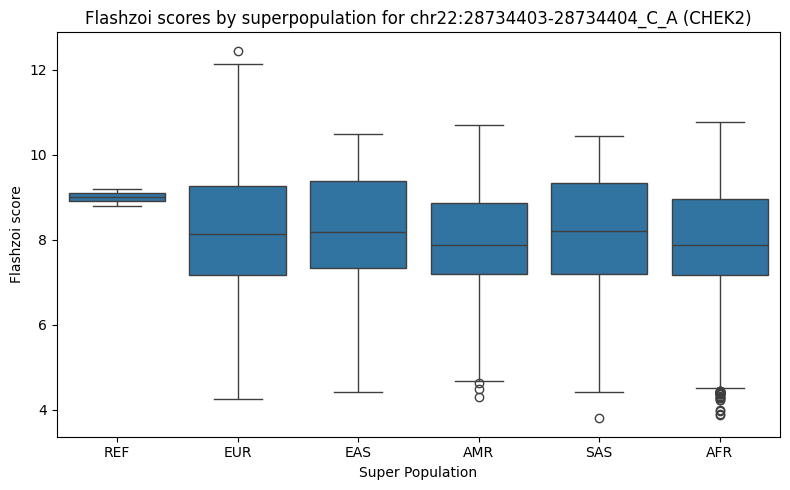

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


top_variant = top_pathogenic.iloc[0]['site']
variant_df = pathogenic_df[pathogenic_df['site'] == top_variant]

plt.figure(figsize=(8, 5))
sns.boxplot(x='Super Population', y='flashzoi', data=variant_df)
plt.title(f"Flashzoi scores by superpopulation for {top_variant} ({variant_df['GENE'].iloc[0]})")
plt.ylabel("Flashzoi score")
plt.xlabel("Super Population")
plt.tight_layout()
plt.show()

## 6. ANOVA: Are Population Differences Significant?

In [16]:
from scipy.stats import f_oneway

groups = [
    group['flashzoi'].dropna().values
    for name, group in variant_df.groupby('Super Population')
    if len(group['flashzoi'].dropna()) > 1
]

if len(groups) > 1:
    stat, pval = f_oneway(*groups)
    print(f"ANOVA p-value for {top_variant}: {pval:.2e}")
else:
    print("Not enough data for ANOVA.")

ANOVA p-value for chr22:28734403-28734404_C_A: 2.86e-11


## 7. Summary Table for Top Variants

In [17]:
summary_cols = ['site', 'GENE', 'CLNSIG', 'CLNSIGCONF', 'flashzoi_var', 'flashzoi_withinpop_var', 'flashzoi_popmean_var']
display(top_pathogenic[summary_cols])

,site,GENE,CLNSIG,CLNSIGCONF,flashzoi_var,flashzoi_withinpop_var,flashzoi_popmean_var
825888,chr22:28734403-28734404_C_A,CHEK2,Pathogenic,None,1.768574,1.700480,0.063903
1422340,chr22:38169219-38169220_G_A,PLA2G6,Pathogenic,None,0.572232,0.590778,0.037048
1707796,chr22:46335768-46335769_C_T,TRMU,Pathogenic/Likely_pathogenic,None,0.218752,0.167426,0.034957
841164,chr22:28734424-28734425_G_A,CHEK2,Pathogenic/Likely_pathogenic,None,0.380395,0.436212,0.018771
1452955,chr22:40346510-40346511_T_C,ADSL,Pathogenic/Likely_pathogenic,None,0.364471,0.459981,0.015034
708655,chr22:23834262-23834263_C_T,SMARCB1,Pathogenic/Likely_pathogenic,None,0.704625,1.419421,0.013600
902347,chr22:28734616-28734617_G_A,CHEK2,Pathogenic/Likely_pathogenic,None,0.068660,0.001298,0.011739
881962,chr22:28734490-28734491_G_A,CHEK2,Pathogenic/Likely_pathogenic,None,0.102951,0.087359,0.008395
1152167,chr22:30958684-30958685_C_T,MORC2,Pathogenic,None,0.486814,0.676262,0.005846
892137,chr22:28734514-28734515_C_A,CHEK2,Pathogenic,None,0.169275,0.170518,0.004732


## Next Steps: Literature Review

| **Variant (rsID)**         | **Genomic Location (GRCh38)**   | **UTR Type** | **Gene** | **Allele Frequency**<br>*1000 Genomes AFR / AMR / EAS / EUR / SAS* | **Clinical Significance**             | **Notes (Clinical Impact / Penetrance)**                                                                                                                                                                                                                                                                                                                                                                                                                               |
| -------------------------- | ------------------------------- | ------------ | -------- | ------------------------------------------------------------------ | ------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| \**c.*96A>G** (rs6151429)  | chr22:50625049 T>C (22q13.33)   | 3′UTR        | ARSA     | **0.4% / 4.0% / 1.8% / 8.2% / 12.0%**                              | Pathogenic† (pseudodeficiency allele) | Disrupts first polyadenylation signal → \~90% reduction in ARSA enzyme activity. Known as a pseudodeficiency allele for metachromatic leukodystrophy (MLD); **does not cause disease by itself**, but can cause very low arylsulfatase A levels and false-positive newborn screens. **Highly population-dependent frequency** (e.g. rare in Africans, more common in Europeans/South Asians), illustrating potential misclassification if population data are ignored. |
| \**c.*82C>T** (no rs)      | chr22:24176618 C>T (22q11.23)‡  | 3′UTR        | SMARCB1  | 0% in 1KGP (not observed)                                          | Pathogenic (Likely pathogenic)        | Identified in *four* unrelated families with **schwannomatosis**. Does not alter coding sequence but causes **unequal allelic mRNA expression** of SMARCB1 (likely disrupting miRNA binding or mRNA stability). Segregates with disease, though with **incomplete penetrance** (some mutation carriers were unaffected). Absent from population databases (private/family-specific variant).                                                                           |
| **c.-66\_-65insT** (no rs) | chr22:29999922\_insT (22q12.2)‡ | 5′UTR        | NF2      | 0% in 1KGP (not observed)                                          | Pathogenic                            | **Frameshift insertion** in the 5′UTR of NF2 (upstream of start codon) that **creates a new uORF**. Disrupts translation of the NF2 tumor-suppressor protein. **Segregates with neurofibromatosis type 2** in multiple families. A newly reported high-penetrance variant (absent in general populations), highlighting that **rare UTR mutations can cause Mendelian disease**.                                                                                       |
| **c.-714C>T** (rs131715)   | chr22:50627761 G>A (22q13.33)   | 5′UTR        | ARSA     | **\~33% global MAF** (common in multiple populations)              | Benign (polymorphism)                 | Common 5′UTR variant in ARSA. **No pathogenic effect** – considered a neutral polymorphism. Its high frequency (\~1/3 globally) far exceeds any reasonable disease allele frequency, and it is present across populations (thus ClinVar/ClinGen classify as benign). Included here as an example of a **population-common UTR variant** on chr22.                                                                                                                      |
| \**c.*919A>G** (rs5770805) | chr22:50625855 A>G (22q13.33)   | 3′UTR        | ARSA     | **\~78% global MAF** (Alt allele is majority in many populations)  | Benign (polymorphism)                 | An extremely common 3′UTR variant in ARSA. One allele is nearly **fixed in some populations** (G is the major allele in many groups). No known clinical impact on ARSA function or disease. Demonstrates a case where the reference allele is actually the minor allele in the global population. Such variants emphasize the importance of understanding ancestral backgrounds – a variant this common is **universally considered benign**.                          |


In [18]:
arsa_df = vep_df_covr[vep_df_covr['GENE'] == 'ARSA']
print(arsa_df[['site', 'CLNSIG', 'flashzoi_popmean_var', 'Super Population']].drop_duplicates())

# Visualize one of the common benign variants
for variant in ['chr22:50627761_G_A', 'chr22:50625855_A_G', 'chr22:50625049_T_C']:
    v = arsa_df[arsa_df['site'] == variant]
    if not v.empty:
        sns.boxplot(x='Super Population', y='flashzoi', data=v)
        plt.title(f"Flashzoi by Super Population for {variant} (ARSA)")
        plt.show()

                                site                        CLNSIG  \
1957632  chr22:50622771-50622772_G_T                 Likely_benign   
1957634  chr22:50622771-50622772_G_T                 Likely_benign   
1958028  chr22:50622771-50622772_G_T                 Likely_benign   
1958112  chr22:50622771-50622772_G_T                 Likely_benign   
1958728  chr22:50622771-50622772_G_T                 Likely_benign   
1959006  chr22:50622771-50622772_G_T                 Likely_benign   
1962730  chr22:50623376-50623377_T_C                        Benign   
1962732  chr22:50623376-50623377_T_C                        Benign   
1963126  chr22:50623376-50623377_T_C                        Benign   
1963210  chr22:50623376-50623377_T_C                        Benign   
1963826  chr22:50623376-50623377_T_C                        Benign   
1964104  chr22:50623376-50623377_T_C                        Benign   
1967828  chr22:50623399-50623400_C_T                        Benign   
1967830  chr22:50623


=== ARSA c.96A>G (rs6151429) (ARSA, position 50625049) ===
                                site        CLNSIG Super Population
1983122  chr22:50625049-50625050_T_C  Benign|other              REF
1983124  chr22:50625049-50625050_T_C  Benign|other              EUR
1983518  chr22:50625049-50625050_T_C  Benign|other              EAS
1983602  chr22:50625049-50625050_T_C  Benign|other              AMR
1984218  chr22:50625049-50625050_T_C  Benign|other              SAS
1984496  chr22:50625049-50625050_T_C  Benign|other              AFR
Overall variance: 0.3627
Variance of population means: 0.0542
Mean within-population variance: 0.3003
ANOVA p-value: 5.22e-37


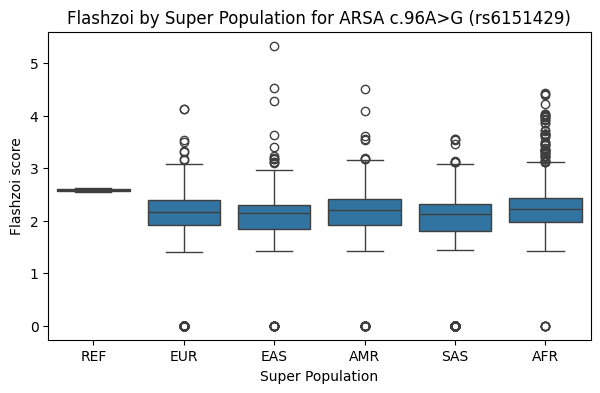


=== ARSA c.-714C>T (rs131715) (ARSA, position 50627761) ===
Variant not found in your data.

=== ARSA c.*919A>G (rs5770805) (ARSA, position 50625855) ===
Variant not found in your data.

=== SMARCB1 c.*82C>T (SMARCB1, position 24176618) ===
Variant not found in your data.

=== NF2 c.-66_-65insT (NF2, position 29999922) ===
Variant not found in your data.


In [19]:
from scipy.stats import f_oneway

# List of all 5 literature variants: (label, gene, position substring)
literature_variants = [
    ('ARSA c.96A>G (rs6151429)', 'ARSA', '50625049'),
    ('ARSA c.-714C>T (rs131715)', 'ARSA', '50627761'),
    ('ARSA c.*919A>G (rs5770805)', 'ARSA', '50625855'),
    ('SMARCB1 c.*82C>T', 'SMARCB1', '24176618'),
    ('NF2 c.-66_-65insT', 'NF2', '29999922'),
]

for label, gene, pos in literature_variants:
    gene_df = vep_df_covr[vep_df_covr['GENE'] == gene]
    matches = gene_df[gene_df['site'].str.contains(pos)]
    print(f"\n=== {label} ({gene}, position {pos}) ===")
    if matches.empty:
        print("Variant not found in your data.")
        continue

    print(matches[['site', 'CLNSIG', 'Super Population']].drop_duplicates())

    overall_var = matches['flashzoi'].var()
    pop_means = matches.groupby('Super Population')['flashzoi'].mean()
    var_of_means = pop_means.var()
    withinpop_var = matches.groupby('Super Population')['flashzoi'].var().mean()

    print(f"Overall variance: {overall_var:.4f}")
    print(f"Variance of population means: {var_of_means:.4f}")
    print(f"Mean within-population variance: {withinpop_var:.4f}")

    groups = [group['flashzoi'].dropna().values for name, group in matches.groupby('Super Population') if len(group['flashzoi'].dropna()) > 1]
    if len(groups) > 1:
        stat, pval = f_oneway(*groups)
        print(f"ANOVA p-value: {pval:.2e}")
    else:
        print("Not enough data for ANOVA.")

    # Optional: visualize
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(7,4))
    sns.boxplot(x='Super Population', y='flashzoi', data=matches)
    plt.title(f"Flashzoi by Super Population for {label}")
    plt.ylabel("Flashzoi score")
    plt.show()

## two examples of chromosome 22 variants with conflicting clinical interpretations in ClinVar that also show population‐specific allele frequencies in the 1000 Genomes Project:

| **Variant (HGVS / rsID)**                                                   | **Gene** | **Chr22 Position (GRCh38)** | **ClinVar Aggregate Classification**                                                                                               | **1000 Genomes Allele Frequencies (by super‐population)** |
| --------------------------------------------------------------------------- | -------- | --------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------- |
| **CHEK2 NM\_007194.4\:c.470T>C (p.Ile157Thr) / rs17879961**                 | CHEK2    | 22:28,725,098 A>G           | Conflicting: submissions range from **Uncertain significance** to **Risk factor** to **Likely pathogenic** ([ncbi.nlm.nih.gov][1]) | • **Global MAF** 0.10% (G) ([ncbi.nlm.nih.gov][1])        |
| • **EUR (Finnish)** \~2.5% ([ncbi.nlm.nih.gov][2])                          |          |                             |                                                                                                                                    |                                                           |
| • **EUR (other)** 0.5–1% (e.g. Estonian \~4.6%) ([ncbi.nlm.nih.gov][1])     |          |                             |                                                                                                                                    |                                                           |
| • **EAS** ≲ 0.1%; **AFR** ≲ 0.1%; **AMR/SAS** ≲ 0.2%                        |          |                             |                                                                                                                                    |                                                           |
| **CHEK2 NM\_007194.4\:c.1111C>T (p.His371Tyr) / no rs (VCV000128044)**      | CHEK2    | 22:29,091,846 G>A           | Conflicting: **Uncertain significance** (12), **Benign** (1), **Likely benign** (3) ([ncbi.nlm.nih.gov][3])                        | • **EAS** 0.42% ([ncbi.nlm.nih.gov][3])                   |
| • **Global / other** < 0.05% (not observed or < 0.1% in AFR, EUR, AMR, SAS) |          |                             |                                                                                                                                    |                                                           |

[1]: https://www.ncbi.nlm.nih.gov/clinvar/variation/5591/ "VCV000005591.115 - ClinVar - NCBI"
[2]: https://www.ncbi.nlm.nih.gov/clinvar/variation/5591/?utm_source=chatgpt.com "VCV000005591.110 - ClinVar - NCBI"
[3]: https://www.ncbi.nlm.nih.gov/clinvar/variation/128044?utm_source=chatgpt.com "ClinVar Genomic variation as it relates to human health - NCBI"
